# UKRDC-stats Benchmarks

The aim of this notebook is to benchmark the performance of the dashboard statistics as the size of the core query, which generates the patient cohort, increases. This benchmark will be calculated using the 3 units with ukrdc feeds as relatively large units these won't necessarily extrapolate to the smaller units. To overcome this the benchmarks will also be run by limiting the size of the query. The size of the query is not directly related to the number of patients, but it can provide an indication of how the system will scale (the accuracy of this assumption will depend on the calculator being used). By profiling different components of the dashboard, we can determine how well the system will perform as the number of patients increases.

In [1]:
# connect to the database
from ukrdc.database import Connection
from sqlalchemy.orm import sessionmaker

engine = Connection.get_engine_from_file(key="ukrdc_live")

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=engine
)

ukrdc3 = ukrdc3_sessionmaker()




# Demographic Stats

Demographic stats currently run pretty quickly (sub 1 second). 

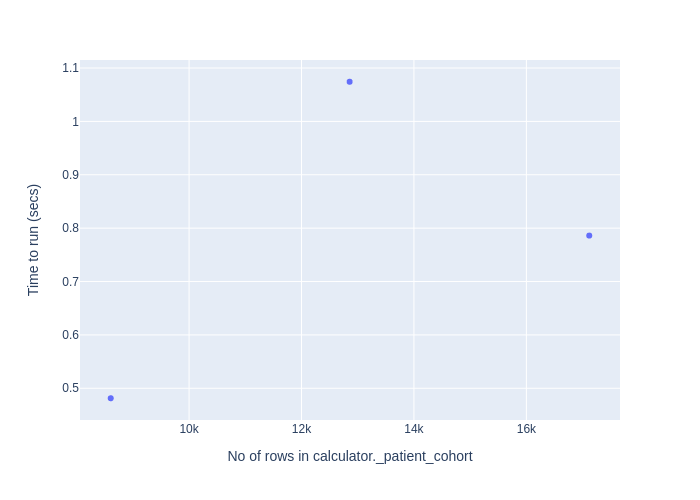

In [2]:
from ukrdc_stats.calculators.demographics import DemographicStatsCalculator
import pandas as pd
import plotly.express as px
from contextlib import contextmanager
from time import perf_counter

@contextmanager
def catchtime():
    start = perf_counter()
    yield lambda: perf_counter() - start


args = {"include_tracing":False, "limit_to_ukrdc":True, "limit_query_length" : None}

units = ["RNJ00", "RJZ", "RFBAK"]
patient_cohort_length = []
time_to_run = []

for unit in units:
    with catchtime() as t:
        calculator = DemographicStatsCalculator(ukrdc3, unit)
        # run function to extract stats
        output = calculator.extract_stats(**args)

    patient_cohort_length.append(len(calculator._patient_cohort))
    time_to_run.append(t())

fig = px.scatter(x=patient_cohort_length, y=time_to_run, labels={"x":"No of rows in calculator._patient_cohort", "y":"Time to run (secs)"})

fig.show("png")

In [3]:
from ukrdc_stats.calculators.demographics import DemographicStatsCalculator
import pandas as pd
import plotly.express as px
from contextlib import contextmanager
from time import perf_counter

@contextmanager
def catchtime():
    start = perf_counter()
    yield lambda: perf_counter() - start


args = {"include_tracing":False, "limit_to_ukrdc":True, "limit_query_length" : None}


patient_cohort_length = []
time_to_run = []

for i in range(10):
    for query_length in range(5000, 20000,5000):
        args["limit_query_length"] = query_length
        with catchtime() as t:
            calculator = DemographicStatsCalculator(ukrdc3, "RNJ00")
            # run function to extract stats
            output = calculator.extract_stats(**args)

        patient_cohort_length.append(len(calculator._patient_cohort))
        time_to_run.append(t())




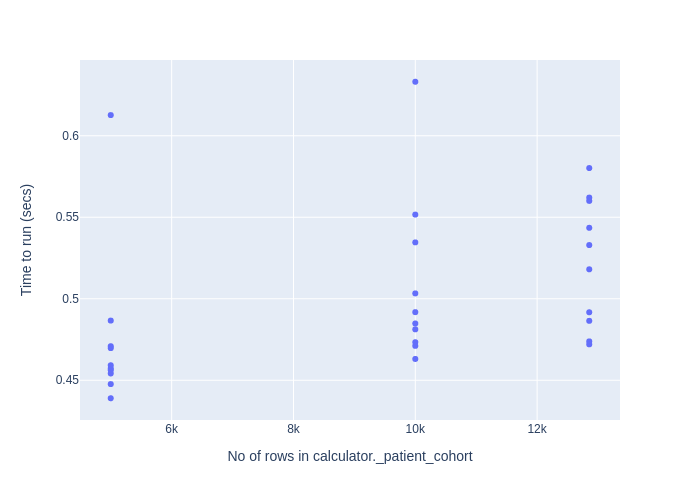

In [4]:
fig = px.scatter(x=patient_cohort_length, y=time_to_run, labels={"x":"No of rows in calculator._patient_cohort", "y":"Time to run (secs)"})
fig.show("png")

Not sure quite how useful this is but it looks like it is showing some (nonlinear) scaling. 

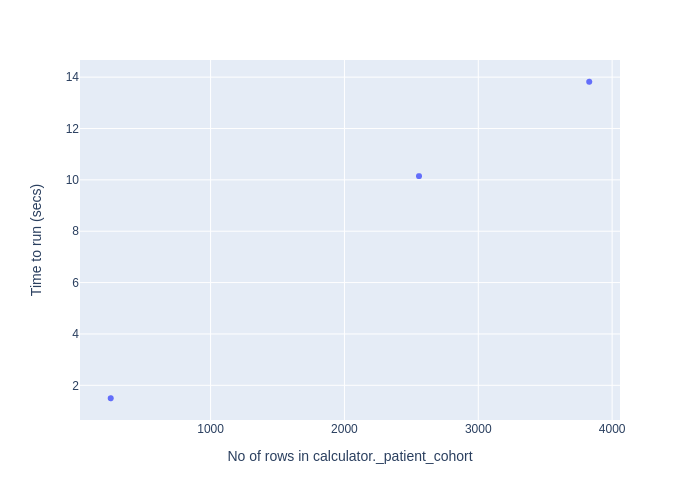

In [5]:
from ukrdc_stats.calculators.dialysis import DialysisStatsCalculator
import plotly.express as px
import datetime as dt
from contextlib import contextmanager
from time import perf_counter

@contextmanager
def catchtime():
    start = perf_counter()
    yield lambda: perf_counter() - start


args = {"limit_to_ukrdc":True, "limit_query_length" : None}

units = ["RNJ00", "RJZ", "RFBAK"]
patient_cohort_length = []
time_to_run = []

for unit in units:
    with catchtime() as t:
        calculator = DialysisStatsCalculator(
            ukrdc3, unit, from_time=dt.datetime(2022, 9, 30), to_time=dt.datetime(2022, 12, 31)
        )
        # run function to extract stats
        output = calculator.extract_stats(**args)

    patient_cohort_length.append(len(calculator._patient_cohort))
    time_to_run.append(t())

fig = px.scatter(x=patient_cohort_length, y=time_to_run,labels={"x":"No of rows in calculator._patient_cohort", "y":"Time to run (secs)"})

fig.show("png")

In [6]:
from ukrdc_stats.calculators.dialysis import DialysisStatsCalculator
import pandas as pd
import plotly.express as px
import datetime as dt

@contextmanager
def catchtime():
    start = perf_counter()
    yield lambda: perf_counter() - start


args = {"limit_to_ukrdc":True, "limit_query_length" : None}


patient_cohort_length = []
time_to_run = []

for query_length in range(1000,6000,500):
    args["limit_query_length"] = query_length
    with catchtime() as t:
        calculator = DialysisStatsCalculator(
            ukrdc3, "RNJ00", from_time=dt.datetime(2021, 12, 31), to_time=dt.datetime(2022, 12, 31)
        )
        # run function to extract stats
        output = calculator.extract_stats(**args)

    patient_cohort_length.append(len(calculator._patient_cohort))
    time_to_run.append(t())




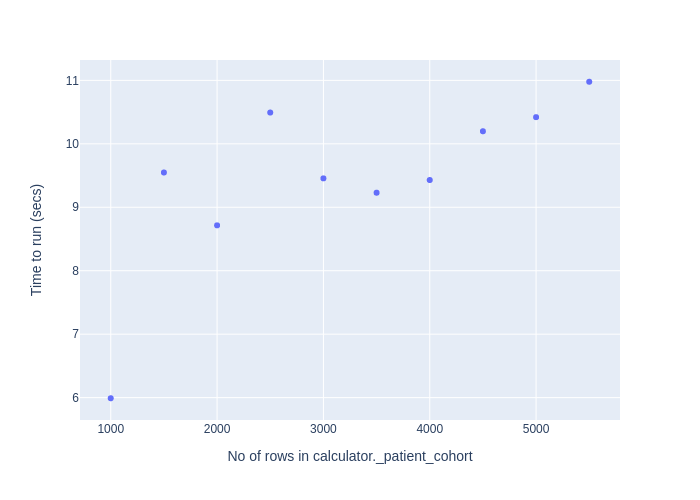

In [7]:
fig = px.scatter(x=patient_cohort_length, y=time_to_run, labels={"x":"No of rows in calculator._patient_cohort", "y":"Time to run (secs)"})
fig.show("png")